In [2]:
import pandas as pd
import matplotlib.pyplot as plt
!pip install wordcloud
from wordcloud import WordCloud

  Using cached wordcloud-1.9.6-cp313-cp313-macosx_11_0_arm64.whl.metadata (3.4 kB)
Using cached wordcloud-1.9.6-cp313-cp313-macosx_11_0_arm64.whl (168 kB)

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [6]:
df = pd.read_csv("../data/processed/final_comments.csv")
df.head(10)

,author,comment,likes,published_at,clean_comment,toxicity_prediction,sentiment
0,@ThomasChisholm-d6q,Who misses him ? \n👇,0,2026-05-26T17:11:42Z,misses,0,Negative
1,@Raphaellarobert07,Miss you 😢😢😢😢😢😢😢😢😢,0,2026-05-26T16:58:40Z,miss,0,Negative
2,@dominicgotti1996,By 4 seconds i already knew how mid this was,0,2026-05-26T14:06:57Z,seconds already knew mid,0,Neutral
3,@Neenee-c2f,his happy lil gaps lol\nbut what did the bat d...,0,2026-05-26T12:45:47Z,happy lil gaps lol bat,0,Positive
4,@squirmyrex49,18:06 demon horse face,0,2026-05-25T16:12:16Z,demon horse face,0,Neutral
5,@timo-y3k2i,Legend never die❤❤❤❤❤❤,1,2026-05-25T08:15:07Z,legend never die,0,Positive
6,@Florian-Hacker,R.I.P Technoblade 😢,0,2026-05-25T07:02:13Z,r p technoblade,0,Negative
7,@chrisrego693,Bye,0,2026-05-25T01:59:25Z,bye,0,Neutral
8,@MahhadGoblin,Bye I hope you go to jannah,0,2026-05-24T19:58:37Z,bye hope go jannah,0,Positive
9,@mariadelaluzpardo4984,Yes wat nou ectus,0,2026-05-24T16:50:31Z,yes wat nou ectus,0,Positive


In [7]:
df["sentiment"].value_counts()

sentiment
Neutral     6867
Positive    5412
Negative    3632
Name: count, dtype: int64

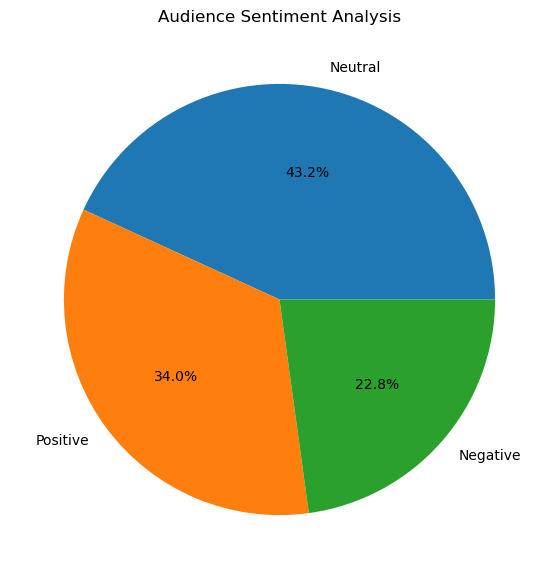

In [8]:
sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%"
)

plt.title("Audience Sentiment Analysis")

plt.show()

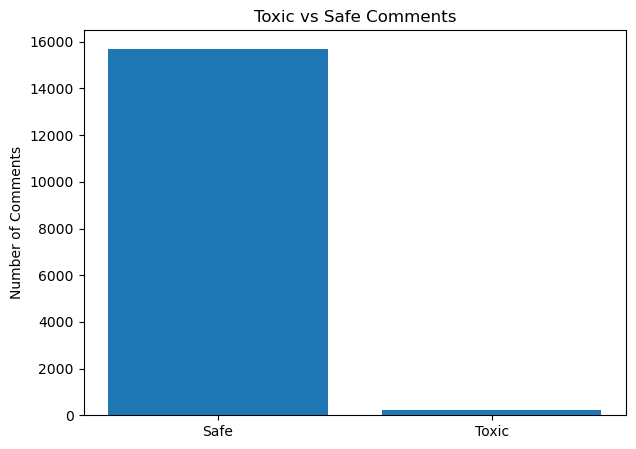

In [9]:
toxicity_counts = df["toxicity_prediction"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(
    ["Safe", "Toxic"],
    toxicity_counts
)

plt.title("Toxic vs Safe Comments")

plt.ylabel("Number of Comments")

plt.show()

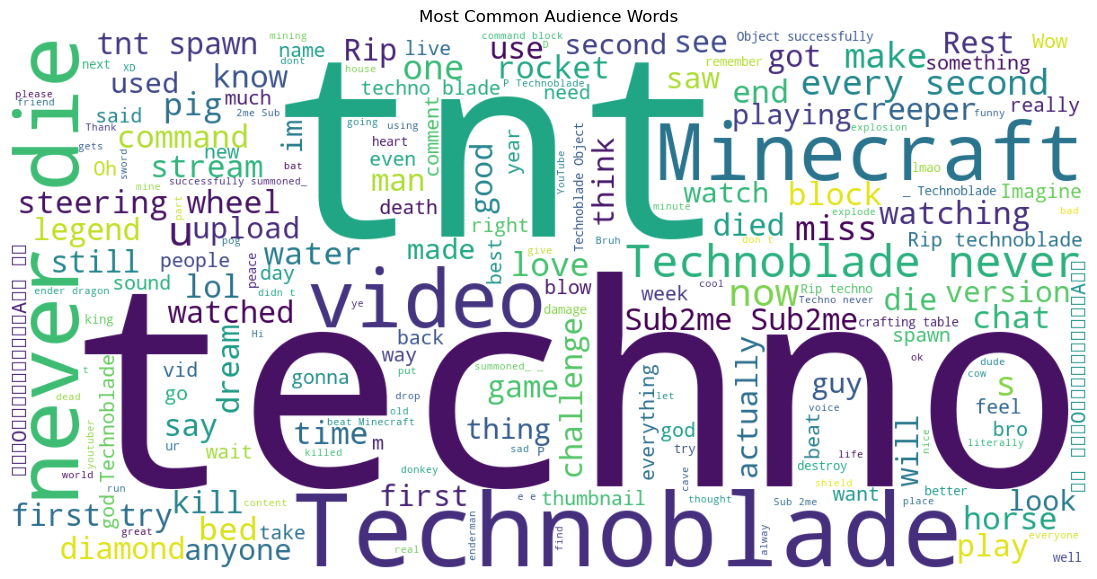

In [10]:
all_words = " ".join(
    df["comment"].astype(str)
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(all_words)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Common Audience Words")

plt.show()

In [11]:
toxic_comments = df[
    df["toxicity_prediction"] == 1
]

toxic_comments[
    ["author", "comment"]
].head(10)

,author,comment
159,@emmy1122,You are the legend you are no king you die in ...
169,@rozhanaetreehamid,Didn't Technoblade die
170,@MichałPaciejewski,Techno Blade neve die
578,@HosniChizungu,Go to the ocean
651,@Watta_world,Damn
723,@Theminecraftmemer,Damn is 😂🎉
874,@ryandove3628,Noooo\nI die
901,@ketchviv,It's 2025...damn
1350,@amongus98223,your legacy will never die\nyou go on in the h...
1877,@Pozitron_11,"17.55:-""You die"". -You too☠️"


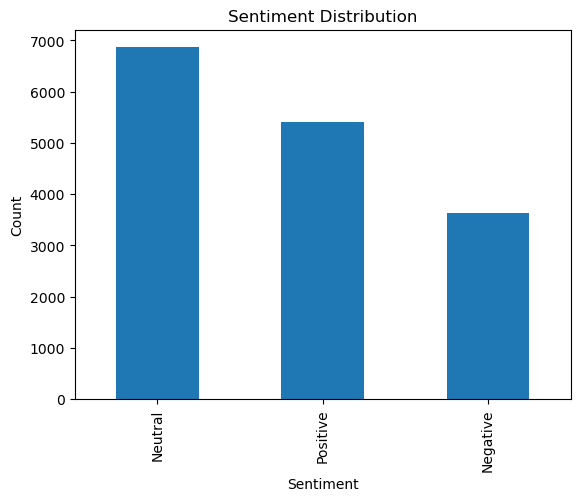

In [12]:
sentiment_counts.plot(
    kind="bar"
)

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

In [13]:
total_comments = len(df)

positive = (
    df["sentiment"] == "Positive"
).sum()

negative = (
    df["sentiment"] == "Negative"
).sum()

neutral = (
    df["sentiment"] == "Neutral"
).sum()

toxic = df["toxicity_prediction"].sum()

print("===== AUDIENCE SUMMARY =====\n")

print(f"Total Comments: {total_comments}")

print(f"Positive Comments: {positive}")

print(f"Negative Comments: {negative}")

print(f"Neutral Comments: {neutral}")

print(f"Toxic Comments: {toxic}")

===== AUDIENCE SUMMARY =====

Total Comments: 15911
Positive Comments: 5412
Negative Comments: 3632
Neutral Comments: 6867
Toxic Comments: 205


In [14]:
positive_ratio = (
    positive / total_comments
) * 100

negative_ratio = (
    negative / total_comments
) * 100

satisfaction_score = (
    positive_ratio - negative_ratio
)

print(
    f"Audience Satisfaction Score: "
    f"{satisfaction_score:.2f}"
)

Audience Satisfaction Score: 11.19


In [15]:
toxic_comments = df[
    df["toxicity_prediction"] == 1
]

toxic_comments[
    ["author", "comment"]
].head(10)

,author,comment
159,@emmy1122,You are the legend you are no king you die in ...
169,@rozhanaetreehamid,Didn't Technoblade die
170,@MichałPaciejewski,Techno Blade neve die
578,@HosniChizungu,Go to the ocean
651,@Watta_world,Damn
723,@Theminecraftmemer,Damn is 😂🎉
874,@ryandove3628,Noooo\nI die
901,@ketchviv,It's 2025...damn
1350,@amongus98223,your legacy will never die\nyou go on in the h...
1877,@Pozitron_11,"17.55:-""You die"". -You too☠️"


In [16]:
top_comments = df.sort_values(
    by="likes",
    ascending=False
)

top_comments[
    ["author", "comment", "likes"]
].head(10)

,author,comment,likes
10937,@faiaz3312,He's been playing bedwars for so long the bed ...,33835
9618,@zara658,“I’m free” - Bedwars win streak\n“I’m free” - ...,21556
5370,@Justap1g,Its incredible how he managed to beat this on ...,15112
8129,@douglasgraham338,So you're saying TNT spawned every 10 seconds ...,13787
8062,@justinprasad7092,*bat explodes*\ntechno: haha\n*crafting table ...,10979
8231,@sittingtreeva927,I love how most of these comments are recent. ...,10313
15387,@oldchannel6038,"Guys, Techno had a perfect run where he didn't...",10102
6840,@leoporto3083,"""I'm actually getting killed"" hes so confused ...",9843
10339,@turbo_jake,“Never listen to the chat the chat hates you”\...,8386
14115,@justyouraveragegamer8733,“Everyone knows the chat never lies”\n\nPewdie...,7661
